In [4]:
from dotenv import load_dotenv
import os
load_dotenv()  # Load environment variables from .env file

True

In [5]:
import os
import requests

class NvidiaChat:
    def __init__(self, model="moonshotai/kimi-k2.5", temperature=0.9):
        self.model = model
        self.temperature = temperature
        self.api_key = os.getenv("NVIDIA_API_KEY")
        self.url = "https://integrate.api.nvidia.com/v1/chat/completions"

        if not self.api_key:
            raise ValueError("Set NVIDIA_API_KEY environment variable")

    def __call__(self, prompt: str) -> str:
        response = requests.post(
            self.url,
            headers={
                "Authorization": f"Bearer {self.api_key}",
                "Content-Type": "application/json",
            },
            json={
                "model": self.model,
                "messages": [{"role": "user", "content": prompt}],
                "temperature": self.temperature,
            },
        )
        return response.json()["choices"][0]["message"]["content"]

In [6]:
chat_llm = NvidiaChat(model="moonshotai/kimi-k2.5", temperature=0.9)

response = chat_llm("What is the capital of France?")
print(response)

 The capital of France is **Paris**.


In [7]:
from typing_extensions import TypedDict,Annotated
import operator

In [8]:
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage, AnyMessage

In [9]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [10]:
def llm_call(state:GraphState)-> dict:
    """Call the LLM using conversation messages and append AI response"""
    prompt = state["messages"][-1].content
    response = chat_llm(prompt)
    return {"messages": [AIMessage(content=response)]}

In [11]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message"""
    last_mag = state["messages"][-1]
    text = last_mag.content
    token_count = len(text.split())
    summary  = f"total token number in the generated response is {token_count}"
    return {"message": [AIMessage(content=summary)]}

In [12]:
from langgraph.graph import StateGraph
builder = StateGraph(GraphState)

In [13]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [14]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [15]:
app = builder.compile()

In [16]:
app.get_graph() 

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [17]:
from IPython.display import Image, display

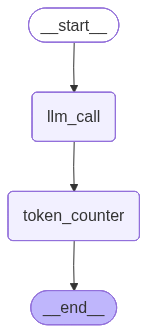

In [18]:
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
result = app.invoke({"messages": [HumanMessage(content="What is the capital of France?")]})
print(result)


{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}), AIMessage(content=' The capital of France is **Paris**.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}


In [20]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [21]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500)

In [22]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [23]:
wiki_tool.run({"query":"what is  genai"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [24]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults()
result = tavily_tool.invoke("currect date and time")
print(result)

C:\Users\vighnesh\AppData\Local\Temp\ipykernel_10696\1200486068.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults()


[{'title': 'Time and Date', 'url': 'https://www.timeanddate.com/', 'content': 'Current Time\n\nWednesday\n\nMar 4, 2026\n\nCharleston, South Carolina, USA\n\nSet home location\n\n2:37:44 am\n\nWorld Clock\n\nImage 2: Illustration of a world map with clocks showing time for Mumbai, New York & Berlin World Clock Current local time around the world.Image 3: Illustration of a hand with two wrist watches showing the time for two different places in the world. Personal World Clock Set the current time of your favorite locations across time zones.\n\nDST changes worldwide\n\nTime Zones [...] Timers\n       Timers Home\n       Stopwatch\n       Timer\n       Countdown to Any Date\n       Spring Countdown\n       Easter Countdown\n       New Year Countdown\n       Countdown for Your Site\n\n   Calculators\n       Calculators Home\n       Date to Date Calculator (duration)\n       Business Date to Date (exclude holidays)\n       Date Calculator (add / subtract)\n       Business Date (exclude hol

In [25]:
from langchain_community.tools import YouTubeSearchTool

In [26]:
youtube_tool = YouTubeSearchTool()

In [27]:
youtube_tool.name

'youtube_search'

In [28]:
youtube_tool.run("campusx")

"['https://www.youtube.com/watch?v=8fX3rOjTloc&pp=ygUHY2FtcHVzeA%3D%3D']"

In [29]:
def multiply(a: int, b: int) -> int:
    return a * b

In [30]:
multiply(3, 4)

12

converting function into tool

In [31]:
from langchain.tools import tool

In [32]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

In [33]:
multiply.invoke({"a": 3, "b": 4})

12

In [34]:
@tool
def get_word_length(word: str) -> int:
    """Returns the length of a word."""
    return len(word)

In [35]:
get_word_length.invoke("word hello")

10

In [36]:
@tool
def call_gamil_api(args):
    """Calls the Gmail API with the provided arguments."""
    pass

In [37]:
import yfinance as yf

In [38]:
@tool 
def get_stock_price(ticker:str)-> str:
    """this is a tool to get stock price using yfinance library"""
    try:
        stock = yf.Ticker(ticker)
        #get last 1 day historical data
        
        data  = stock.history(period="1d")
        if data.empty:
            return f"No data found for ticker {ticker} . Please check the symbol."
        
        lastest_close = data["Close"].iloc[-1]
        
        #Detect currency
        currency = stock.info.get("currency", "")
        symbol_map ={
            "INR":"₹",
            "USD":"$",
            "EUR":"€",
            "GBP":"£",
        }
        
        symbol = symbol_map.get(currency, "")
        curreny_text = currency if currency else ""
        if symbol:
            return f"the last closing price of {ticker.upper()} was {symbol}{lastest_close:.2f}."
        else:
            return f"the last closing price of {ticker.upper()} was {lastest_close:.2f} {curreny_text}."
    except Exception as e:
        return f"An error occurred while fetching stock price for {ticker}: {str(e)}"

In [39]:
get_stock_price.invoke("AAPL")

'the last closing price of AAPL was $263.79.'

In [40]:
get_stock_price.invoke("TSLA")

'the last closing price of TSLA was $404.38.'

In [41]:
get_stock_price.invoke("HDFCBANK.NS")

'the last closing price of HDFCBANK.NS was ₹868.65.'

In [42]:
tools = [get_word_length, multiply, get_stock_price,wiki_tool]

In [43]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    groq_api_key=os.getenv("GROQ_API_KEY")
)

llm_with_tools = llm.bind_tools(tools)

In [44]:
result = llm_with_tools.invoke("What is the current Tesla stock price?")   

In [45]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7zwhm6r7m', 'function': {'arguments': '{"ticker":"TSLA"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 460, 'total_tokens': 477, 'completion_time': 0.025560275, 'completion_tokens_details': None, 'prompt_time': 0.039567069, 'prompt_tokens_details': None, 'queue_time': 0.046916351, 'total_time': 0.065127344}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cba13-34d3-77c2-9ca8-b77cbff59497-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TSLA'}, 'id': '7zwhm6r7m', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 460, 'output_tokens': 17, 'total_tokens': 477})

In [46]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TSLA'},
  'id': '7zwhm6r7m',
  'type': 'tool_call'}]

In [47]:
results = llm_with_tools.invoke("how many words are there in the sentence 'Agentic AI is the future of artificial intelligence.'?")

In [48]:
results

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wwhcmsz82', 'function': {'arguments': '{"word":"Agentic AI is the future of artificial intelligence."}', 'name': 'get_word_length'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 472, 'total_tokens': 495, 'completion_time': 0.027513862, 'completion_tokens_details': None, 'prompt_time': 0.030854453, 'prompt_tokens_details': None, 'queue_time': 0.046666419, 'total_time': 0.058368315}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cba13-3626-7521-9839-e236672b439b-0', tool_calls=[{'name': 'get_word_length', 'args': {'word': 'Agentic AI is the future of artificial intelligence.'}, 'id': 'wwhcmsz82', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 472, 'output_tokens': 23, 'total_tokens': 495})

In [49]:
results.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'Agentic AI is the future of artificial intelligence.'},
  'id': 'wwhcmsz82',
  'type': 'tool_call'}]

In [50]:
result1 = llm_with_tools.invoke("can u multiply 6 and 7?")

In [51]:
result1.content

''

In [52]:
result1.tool_calls

[{'name': 'multiply',
  'args': {'a': 6, 'b': 7},
  'id': 'c67ebhnsz',
  'type': 'tool_call'}]

In [53]:
result2= llm_with_tools.invoke("what is 2026 indin bugget?")

In [54]:
result2

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ha65jy84v', 'function': {'arguments': '{"query":"India budget 2026"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': '8kjq3e8gr', 'function': {'arguments': '{"query":"India budget 2026"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': '8znvces7b', 'function': {'arguments': '{"query":"India budget 2026"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': 'v1kt22rf5', 'function': {'arguments': '{"query":"India budget 2026"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': '58g7nybet', 'function': {'arguments': '{"query":"India budget 2026"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': 'yh98r8ge6', 'function': {'arguments': '{"query":"India budget 2026"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': '0v6wjn164', 'function': {'arguments': '{"query":"India budget 2026"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': '2ka20hqvx', 'function': {'arguments': '{"query":"India budget 2026"}', 'name': 'wi

In [55]:
result2.content

''

In [56]:
result2.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': 'ha65jy84v',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': '8kjq3e8gr',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': '8znvces7b',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': 'v1kt22rf5',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': '58g7nybet',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': 'yh98r8ge6',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': '0v6wjn164',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': '2ka20hqvx',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': 'gs3rzmf06',
  'type': 'tool_call'},
 {'name': 

ReAct

In [57]:
from langchain_core.messages import HumanMessage ,AIMessage
from langgraph.graph import MessagesState, StateGraph, END,START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


In [58]:
def function_1(state: MessagesState):
    pass

In [59]:
tools

[StructuredTool(name='get_word_length', description='Returns the length of a word.', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x0000016FF7D9D300>),
 StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000016FF76E2160>),
 StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance library', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x0000016F9234E980>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\vighnesh\\project\\AgenticAI_project\\env\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [60]:
function_2  = ToolNode(tools)

In [61]:
workflow  = StateGraph(MessagesState)

In [62]:
workflow.add_node("llm", function_1)

In [67]:
workflow.add_node("tools", function_2)

In [63]:
workflow.add_edge(START, "llm")

In [ ]:
workflow.add_conditional_edges(
    "llm", 
    tools_condition
)

In [64]:
workflow.add_edge("tools","llm")

In [68]:
app = workflow.compile()

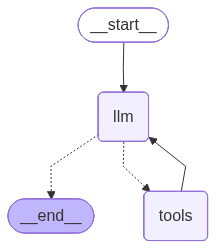

In [70]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))